In [1]:
!pip install pandas-datareader

In [2]:
import pandas_datareader as pdr
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import statsmodels.api as sms
from datetime import datetime

In [3]:
df=pdr.get_data_yahoo('TATAMOTORS.NS')
df.head(3)

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2017-12-05,405.500000,396.549988,404.549988,402.250000,7144542,402.250000
2017-12-06,404.000000,395.000000,400.200012,397.049988,5573968,397.049988
2017-12-07,405.299988,397.149994,398.000000,402.000000,7998863,402.000000


In [4]:
df.tail(3)

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2022-11-30,441.000000,433.299988,435.0,439.399994,14727892,439.399994
2022-12-01,443.600006,436.850006,443.0,438.250000,8909310,438.250000
2022-12-02,441.149994,435.000000,439.0,435.399994,8352658,435.399994


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1234 entries, 2017-12-05 to 2022-12-02
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   High       1234 non-null   float64
 1   Low        1234 non-null   float64
 2   Open       1234 non-null   float64
 3   Close      1234 non-null   float64
 4   Volume     1234 non-null   int64  
 5   Adj Close  1234 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 67.5 KB


In [6]:
df.shape

(1234, 6)

<AxesSubplot:xlabel='Date'>

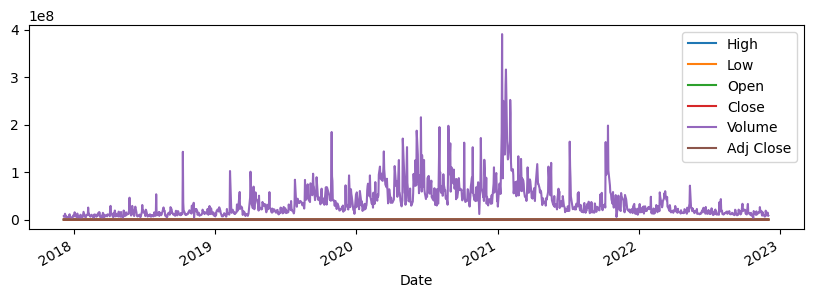

In [7]:
df.plot(figsize=(10,3))

<AxesSubplot:xlabel='Date'>

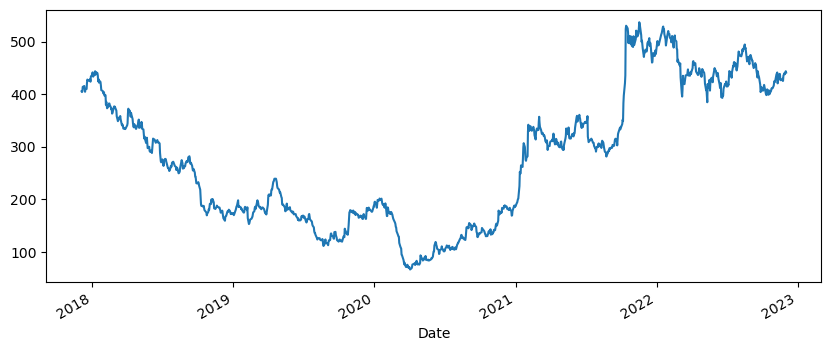

In [8]:
df['High'].plot(figsize=(10,4))

<AxesSubplot:xlabel='Date'>

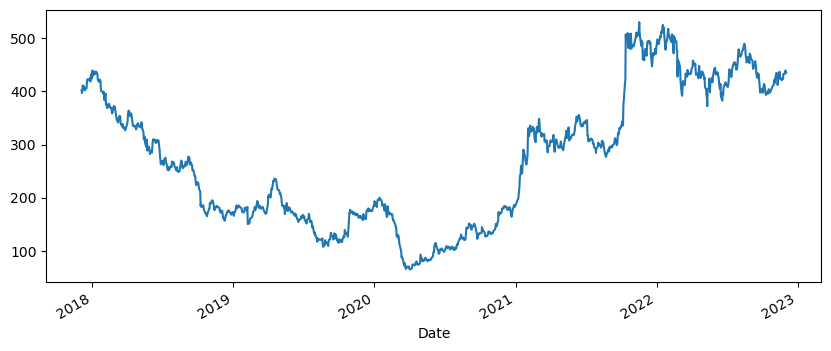

In [9]:
df['Close'].plot(figsize=(10,4))

<AxesSubplot:xlabel='Date'>

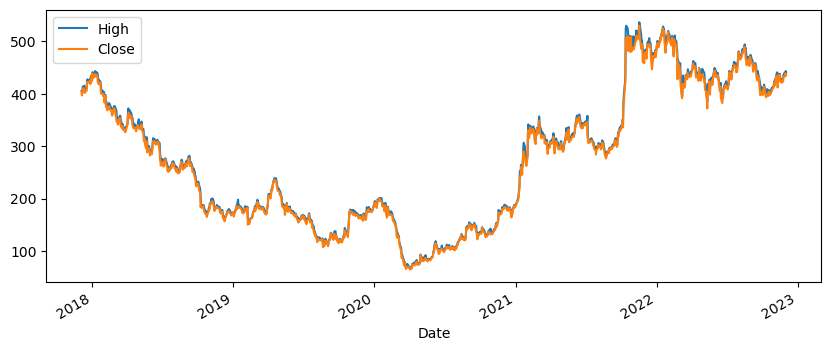

In [10]:
df[['High','Close']].plot(figsize=(10,4))

<AxesSubplot:xlabel='Date'>

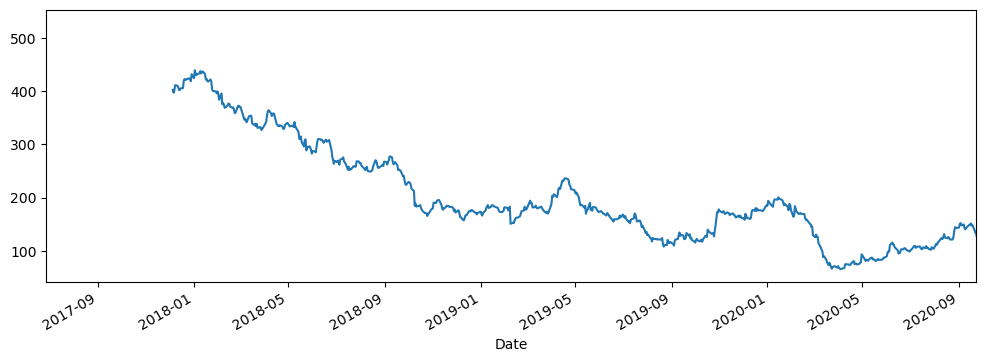

In [11]:
## xlimit and y limit
df['Close'].plot(xlim=['2017-06-27','2020-09-23'],figsize=(12,4))
# df['High'].plot(xlim=['2017-06-27','2020-09-23'])

<AxesSubplot:xlabel='Date'>

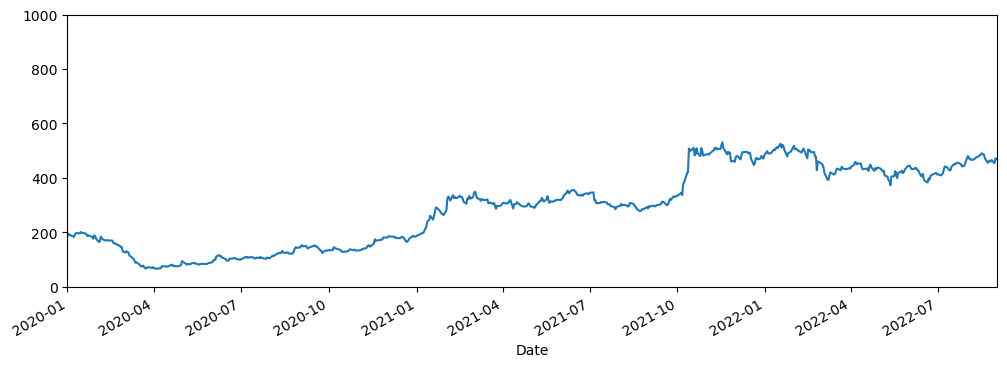

In [12]:
df['Close'].plot(xlim=['2020-01-01','2022-09-01'],ylim=[0,1000],figsize=(12,4))

In [13]:
df.index

DatetimeIndex(['2017-12-05', '2017-12-06', '2017-12-07', '2017-12-08',
               '2017-12-11', '2017-12-12', '2017-12-13', '2017-12-14',
               '2017-12-15', '2017-12-18',
               ...
               '2022-11-21', '2022-11-22', '2022-11-23', '2022-11-24',
               '2022-11-25', '2022-11-28', '2022-11-29', '2022-11-30',
               '2022-12-01', '2022-12-02'],
              dtype='datetime64[ns]', name='Date', length=1234, freq=None)

# Time Resampling

In [14]:
df.resample(rule='A').min() 
#It gives us MIN values of all parameters in each year.

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2017-12-31,404.000000,389.299988,398.000000,397.049988,3673355,397.049988
2018-12-31,159.500000,154.649994,155.000000,157.100006,3820313,157.100006
2019-12-31,111.599998,106.000000,108.900002,107.699997,6141180,107.699997
2020-12-31,66.900002,63.500000,66.500000,65.300003,11749453,65.300003
2021-12-31,187.000000,184.500000,184.949997,186.500000,5531940,186.500000
2022-12-31,384.649994,366.200012,382.000000,372.299988,2871205,372.299988


In [15]:
df.resample(rule='A').max()  
#It gives us MAX values of all parameters in each year.

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2017-12-31,433.450012,421.149994,424.000000,431.850006,12288946,431.850006
2018-12-31,443.500000,433.000000,440.399994,439.299988,142760251,439.299988
2019-12-31,239.350006,231.699997,235.000000,236.250000,184435614,236.250000
2020-12-31,201.699997,196.899994,199.500000,200.350006,215476711,200.350006
2021-12-31,536.700012,520.250000,531.450012,530.150024,390577839,530.150024
2022-12-31,528.500000,512.000000,527.900024,525.000000,71425747,525.000000


<AxesSubplot:xlabel='Date'>

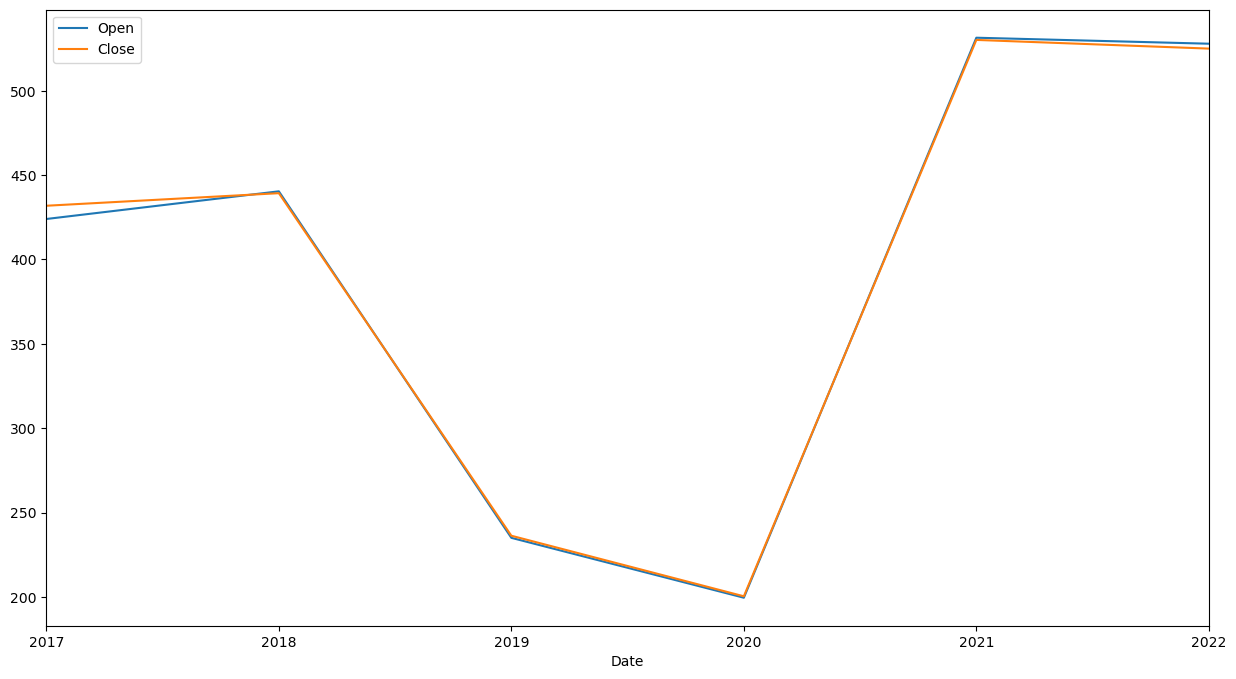

In [16]:
##rule = A : year end frequency
df.resample(rule='A').max()[['Open','Close']].plot(figsize=(15,8))
# PLOT open max price over the year

In [17]:
df.resample(rule='QS').max()
##RULE QS : quaterly start frequency--> after three months

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2017-10-01,433.450012,421.149994,424.000000,431.850006,12288946,431.850006
2018-01-01,443.500000,433.000000,440.399994,439.299988,25294860,439.299988
2018-04-01,372.350006,359.799988,362.600006,364.100006,46104103,364.100006
2018-07-01,282.000000,272.899994,277.250000,277.399994,53282545,277.399994
2018-10-01,232.800003,225.800003,230.000000,229.350006,142760251,229.350006
2019-01-01,198.350006,187.800003,195.399994,194.050003,102256857,194.050003
2019-04-01,239.350006,231.699997,235.000000,236.250000,100834335,236.250000
2019-07-01,172.350006,166.300003,170.000000,170.000000,96568372,170.000000
2019-10-01,187.899994,181.550003,184.000000,185.149994,184435614,185.149994


<AxesSubplot:xlabel='Date'>

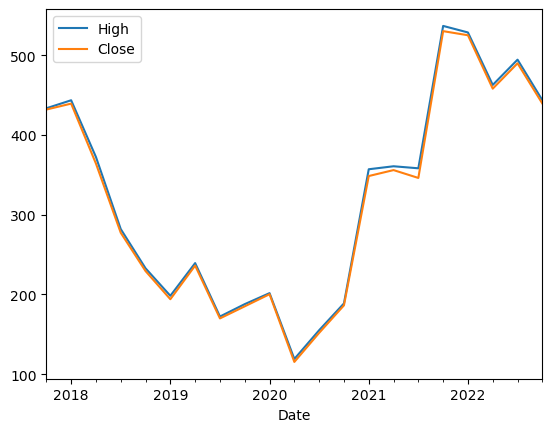

In [18]:
##RULE QS : quaterly start frequency--> after three months 
##https://towardsdatascience.com/resample-function-of-pandas-79b17ec82a78
df.resample(rule='QS').max()[['High','Close']].plot()

In [19]:
##RULE BA : Business End Frequency
##https://towardsdatascience.com/resample-function-of-pandas-79b17ec82a78
df.resample(rule='BA').max()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2017-12-29,433.450012,421.149994,424.000000,431.850006,12288946,431.850006
2018-12-31,443.500000,433.000000,440.399994,439.299988,142760251,439.299988
2019-12-31,239.350006,231.699997,235.000000,236.250000,184435614,236.250000
2020-12-31,201.699997,196.899994,199.500000,200.350006,215476711,200.350006
2021-12-31,536.700012,520.250000,531.450012,530.150024,390577839,530.150024
2022-12-30,528.500000,512.000000,527.900024,525.000000,71425747,525.000000


In [20]:
df.resample(rule='BQS').max()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2017-10-02,433.450012,421.149994,424.000000,431.850006,12288946,431.850006
2018-01-01,443.500000,433.000000,440.399994,439.299988,25294860,439.299988
2018-04-02,372.350006,359.799988,362.600006,364.100006,46104103,364.100006
2018-07-02,282.000000,272.899994,277.250000,277.399994,53282545,277.399994
2018-10-01,232.800003,225.800003,230.000000,229.350006,142760251,229.350006
2019-01-01,198.350006,187.800003,195.399994,194.050003,102256857,194.050003
2019-04-01,239.350006,231.699997,235.000000,236.250000,100834335,236.250000
2019-07-01,172.350006,166.300003,170.000000,170.000000,96568372,170.000000
2019-10-01,187.899994,181.550003,184.000000,185.149994,184435614,185.149994


<AxesSubplot:xlabel='Date'>

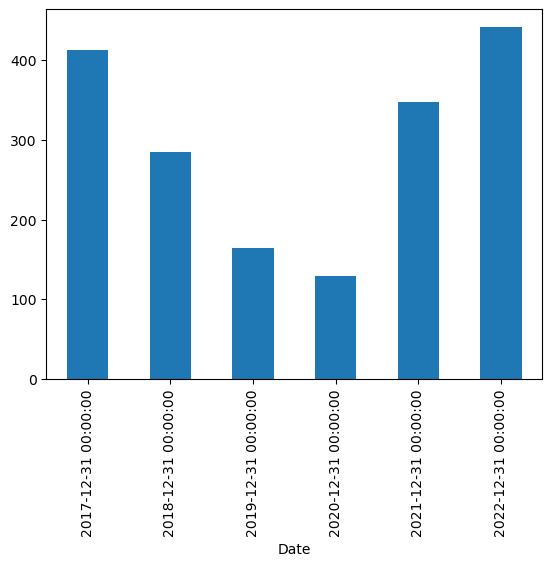

In [21]:
##plotting
df['Close'].resample(rule='A').mean().plot(kind='bar')

<AxesSubplot:xlabel='Date'>

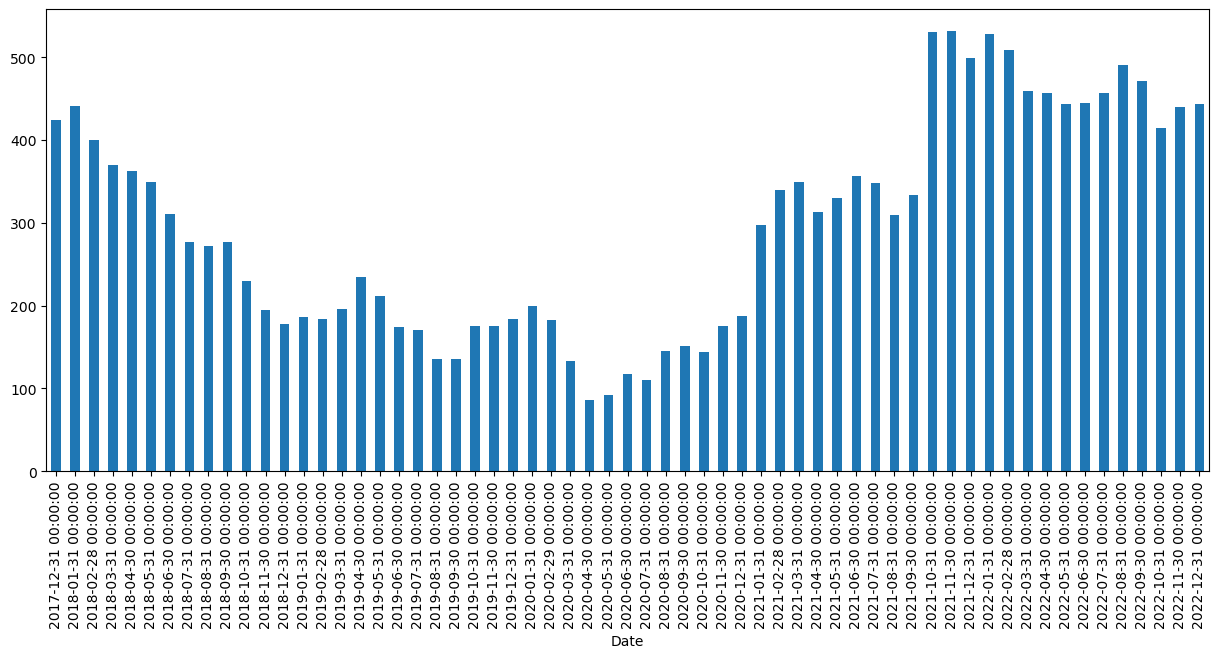

In [22]:
# RULE M : monthly data
df['Open'].resample(rule='M').max().plot(kind='bar',figsize=(15,6))

In [23]:
df['High'].rolling(11).mean().head(20)

Date
2017-12-05           NaN
2017-12-06           NaN
2017-12-07           NaN
2017-12-08           NaN
2017-12-11           NaN
2017-12-12           NaN
2017-12-13           NaN
2017-12-14           NaN
2017-12-15           NaN
2017-12-18           NaN
2017-12-19    410.386364
2017-12-20    412.409091
2017-12-21    414.413635
2017-12-22    416.331818
2017-12-26    417.368181
2017-12-27    418.572726
2017-12-28    419.318182
2017-12-29    421.463637
2018-01-01    424.359092
2018-01-02    427.254547
Name: High, dtype: float64

In [24]:
df['High'].rolling(11).max().head(20)

Date
2017-12-05           NaN
2017-12-06           NaN
2017-12-07           NaN
2017-12-08           NaN
2017-12-11           NaN
2017-12-12           NaN
2017-12-13           NaN
2017-12-14           NaN
2017-12-15           NaN
2017-12-18           NaN
2017-12-19    421.700012
2017-12-20    427.750000
2017-12-21    427.750000
2017-12-22    427.750000
2017-12-26    427.750000
2017-12-27    428.450012
2017-12-28    428.450012
2017-12-29    433.450012
2018-01-01    436.399994
2018-01-02    440.850006
Name: High, dtype: float64

In [25]:
df.head()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2017-12-05,405.500000,396.549988,404.549988,402.250000,7144542,402.250000
2017-12-06,404.000000,395.000000,400.200012,397.049988,5573968,397.049988
2017-12-07,405.299988,397.149994,398.000000,402.000000,7998863,402.000000
2017-12-08,413.750000,406.000000,406.000000,411.149994,12288946,411.149994
2017-12-11,415.200012,409.049988,412.000000,410.149994,5066242,410.149994


In [26]:
# simple moving average
df['Open:30 days rolling']=df['Open'].rolling(30).mean()

In [27]:
df.head(31)

,High,Low,Open,Close,Volume,Adj Close,Open:30 days rolling
Date,,,,,,,
2017-12-05,405.500000,396.549988,404.549988,402.250000,7144542,402.250000,NaN
2017-12-06,404.000000,395.000000,400.200012,397.049988,5573968,397.049988,NaN
2017-12-07,405.299988,397.149994,398.000000,402.000000,7998863,402.000000,NaN
2017-12-08,413.750000,406.000000,406.000000,411.149994,12288946,411.149994,NaN
2017-12-11,415.200012,409.049988,412.000000,410.149994,5066242,410.149994,NaN
2017-12-12,415.500000,405.950012,411.549988,406.850006,6151197,406.850006,NaN
2017-12-13,409.850006,400.000000,407.000000,401.950012,5140689,401.950012,NaN
2017-12-14,404.549988,398.200012,404.000000,402.399994,4674026,402.399994,NaN
2017-12-15,409.000000,404.200012,406.500000,405.100006,5614113,405.100006,NaN


<AxesSubplot:xlabel='Date'>

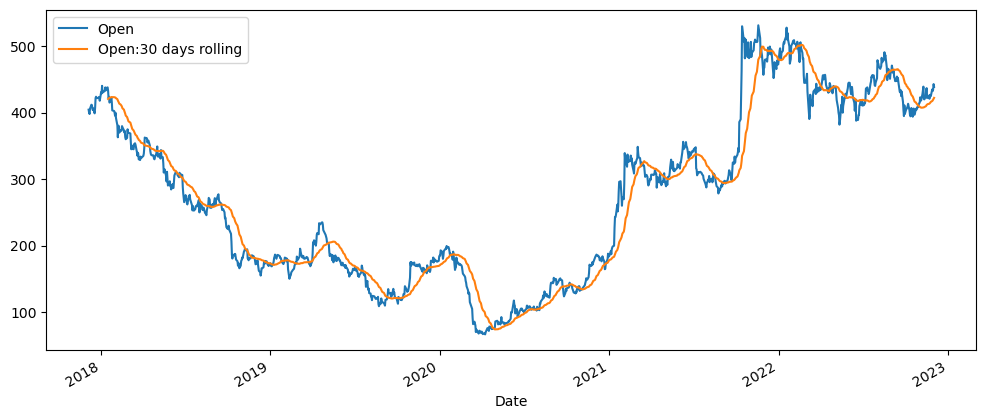

In [28]:
df[['Open','Open:30 days rolling']].plot(figsize=(12,5))

<AxesSubplot:xlabel='Date'>

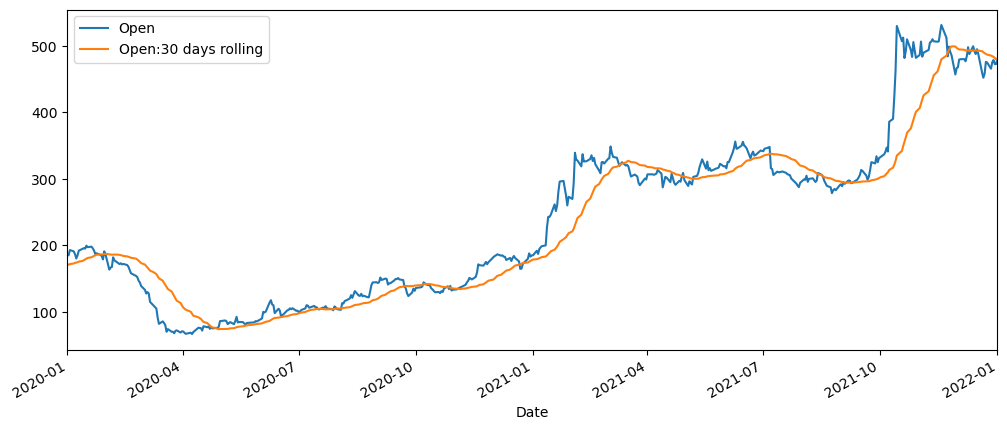

In [29]:
# here we specify xlim 
df[['Open','Open:30 days rolling']].plot(xlim=['2020-01-01','2022-01-01'],figsize=(12,5))

In [30]:
df['Open:10 days rolling']=df['Open'].rolling(10).mean()
df['Open:30 days rolling']=df['Open'].rolling(30).mean()
df['Open:50 days rolling']=df['Open'].rolling(50).mean()

<AxesSubplot:xlabel='Date'>

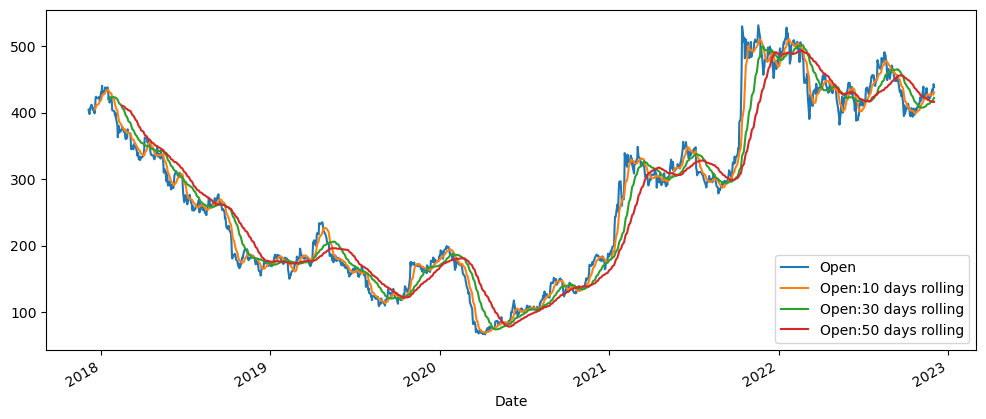

In [31]:
df[['Open','Open:10 days rolling','Open:30 days rolling','Open:50 days rolling']].plot(figsize=(12,5))

<AxesSubplot:xlabel='Date'>

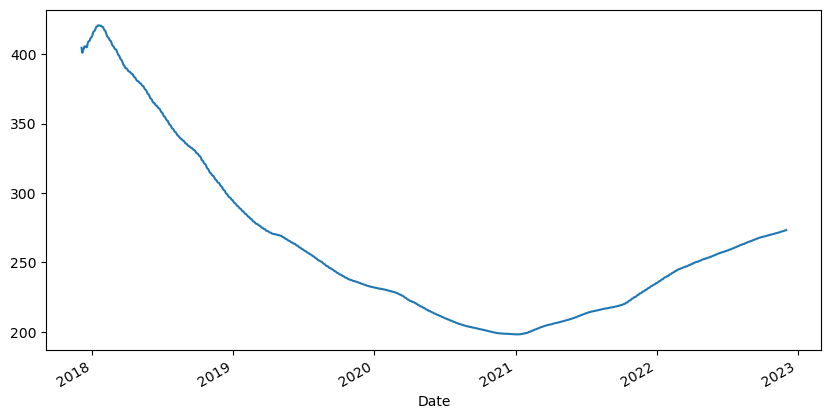

In [32]:
# cumulative moving average(here I use for only open stock)
# use expanding
df['Open'].expanding().mean().plot(figsize=(10,5))

In [33]:
#  exponential moving average
df['EMA_0.1'] = df['Open'].ewm(alpha=0.1, adjust=False).mean()

<AxesSubplot:xlabel='Date'>

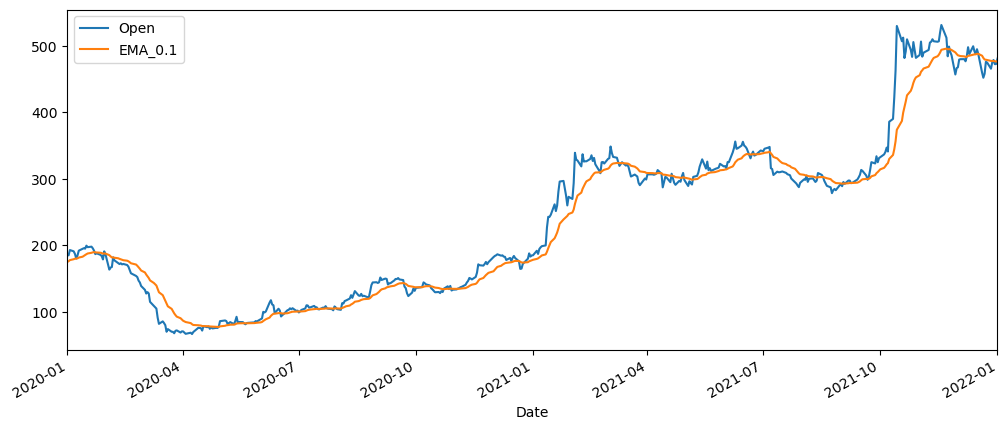

In [34]:
df[['Open','EMA_0.1']].plot(xlim=['2020-01-01','2022-01-01'],figsize=(12,5))

In [35]:
df['EMA_0.3'] = df['Open'].ewm(alpha=0.3, adjust=False).mean()

<AxesSubplot:xlabel='Date'>

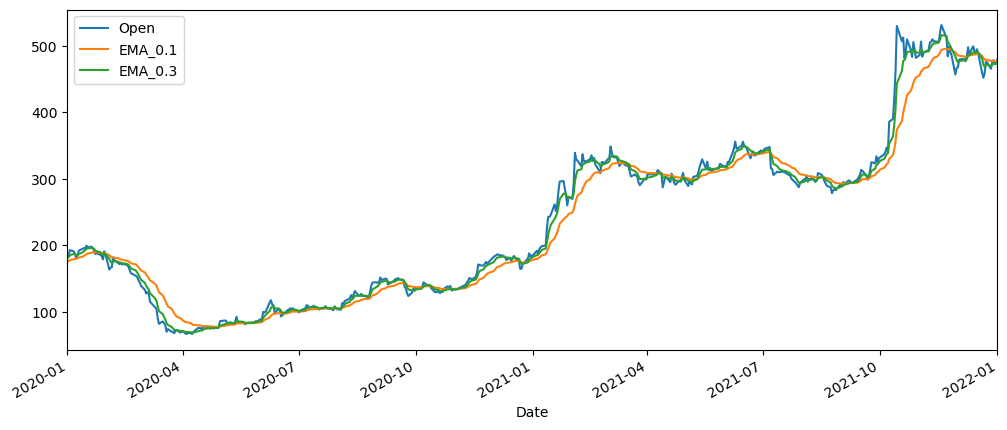

In [36]:
df[['Open','EMA_0.1','EMA_0.3']].plot(xlim=['2020-01-01','2022-01-01'],figsize=(12,5))

In [37]:
# exponential weightage moving average -- more smoothen curve
df['EWMA_5days'] = df['Open'].ewm(span=5).mean()

<AxesSubplot:xlabel='Date'>

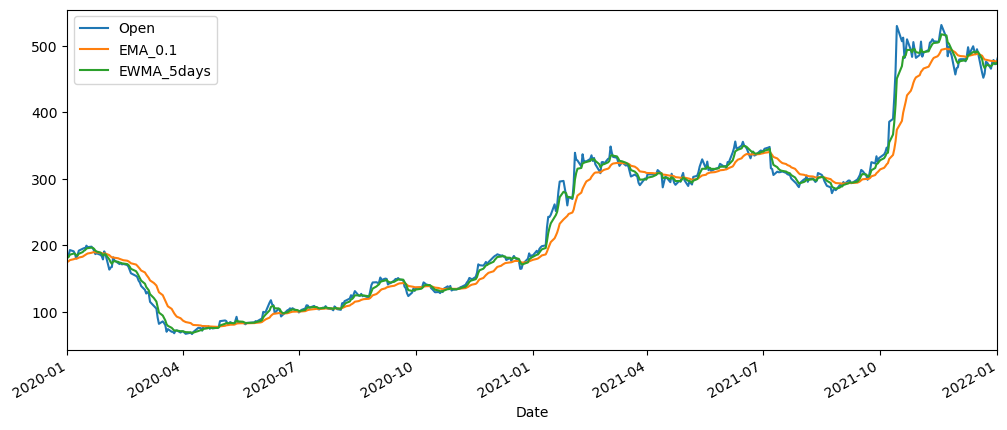

In [38]:
df[['Open','EMA_0.1','EWMA_5days']].plot(xlim=['2020-01-01','2022-01-01'],figsize=(12,5))

In [39]:
df['EMA_0.33333'] = df['Open'].ewm(alpha=0.33333, adjust=False).mean()

<AxesSubplot:xlabel='Date'>

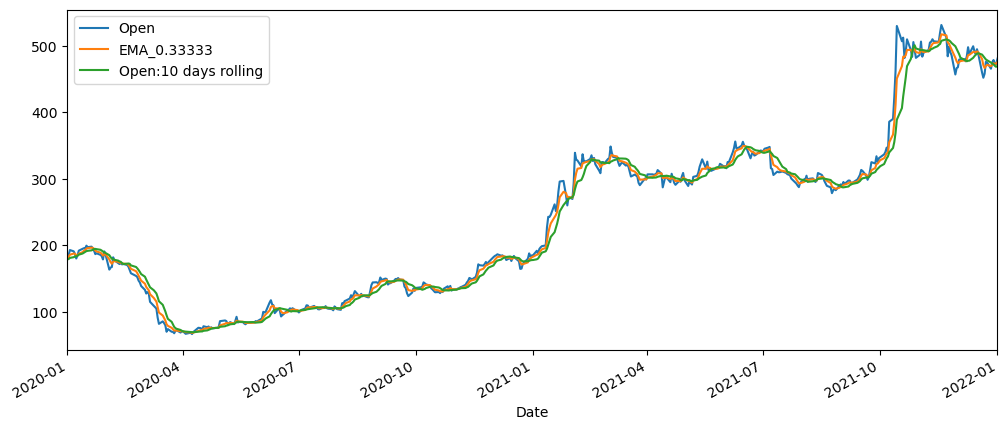

In [42]:
df[['Open','EMA_0.33333','Open:10 days rolling']].plot(xlim=['2020-01-01','2022-01-01'],figsize=(12,5))

<AxesSubplot:xlabel='Date'>

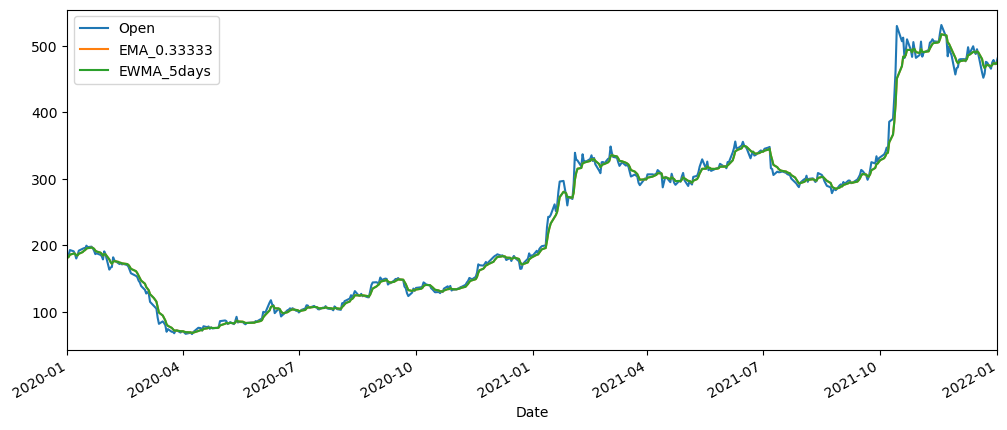

In [40]:
df[['Open','EMA_0.33333','EWMA_5days']].plot(xlim=['2020-01-01','2022-01-01'],figsize=(12,5))
# both alpha =0.3 and span =5 is same almost 

In [40]:
df

,High,Low,Open,Close,Volume,Adj Close,Open:30 days rolling,Open:10 days rolling,Open:50 days rolling,EMA_0.1,EMA_0.3,EWMA_5days,EMA_0.33333
Date,,,,,,,,,,,,,
2017-11-15,417.549988,407.000000,414.299988,408.649994,9867270,408.649994,NaN,NaN,NaN,414.299988,414.299988,414.299988,414.299988
2017-11-16,415.899994,411.350006,411.350006,413.450012,6291441,413.450012,NaN,NaN,NaN,414.004990,413.414993,412.529999,413.316670
2017-11-17,423.450012,417.000000,419.450012,421.799988,6191428,421.799988,NaN,NaN,NaN,414.549492,415.225499,415.807900,415.361097
2017-11-20,425.700012,420.100006,421.000000,423.000000,4051153,423.000000,NaN,NaN,NaN,415.194543,416.957849,417.964618,417.240713
2017-11-21,430.000000,422.500000,424.450012,424.250000,6745407,424.250000,NaN,NaN,NaN,416.120090,419.205498,420.454272,419.643788
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-07,437.500000,428.250000,428.250000,435.000000,15058076,435.000000,407.631665,414.504999,424.952,413.301057,419.942082,420.718493,420.718422
2022-11-09,441.200012,432.000000,439.200012,433.149994,14471443,433.149994,407.874999,417.825000,424.416,415.890953,425.719461,426.879000,426.878890
2022-11-10,420.549988,409.200012,420.500000,412.200012,26251660,412.200012,408.024999,419.439999,423.526,416.351857,424.153623,424.752666,424.752615


# STAT MODEL WITH ARIMA

In [41]:
# since it is seasonal data we are going to use dickey fuller test
from statsmodels.tsa.stattools import adfuller

In [42]:
# H0 : It is not stationary
# H1 : It is stationary

In [43]:
def adf_test(series):
    result=adfuller(series)
    print('ADF Statistics: {}'.format(result[0]))
    print('p- value: {}'.format(result[1]))
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

In [44]:
df1=pdr.get_data_yahoo('TATAMOTORS.NS')
df1.head(3)

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2017-11-15,417.549988,407.000000,414.299988,408.649994,9867270,408.649994
2017-11-16,415.899994,411.350006,411.350006,413.450012,6291441,413.450012
2017-11-17,423.450012,417.000000,419.450012,421.799988,6191428,421.799988


In [45]:
adf_test(df1['Close'])

ADF Statistics: -1.1082696871796736
p- value: 0.7117628071950646
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


In [46]:
## Use Techniques Differencing -- one dayy differencing to convery into stationary data
# we can;t work with seasonal data
df1['first_diff_Close']=df1['Close']-df1['Close'].shift(1)

In [47]:
df1.head()

,High,Low,Open,Close,Volume,Adj Close,first_diff_Close
Date,,,,,,,
2017-11-15,417.549988,407.000000,414.299988,408.649994,9867270,408.649994,NaN
2017-11-16,415.899994,411.350006,411.350006,413.450012,6291441,413.450012,4.800018
2017-11-17,423.450012,417.000000,419.450012,421.799988,6191428,421.799988,8.349976
2017-11-20,425.700012,420.100006,421.000000,423.000000,4051153,423.000000,1.200012
2017-11-21,430.000000,422.500000,424.450012,424.250000,6745407,424.250000,1.250000


In [48]:
adf_test(df1['first_diff_Close'].dropna())

ADF Statistics: -9.096671144089308
p- value: 3.699036481983448e-15
strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary


In [49]:
# now time to determine p(pacf) and q(acf) value
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

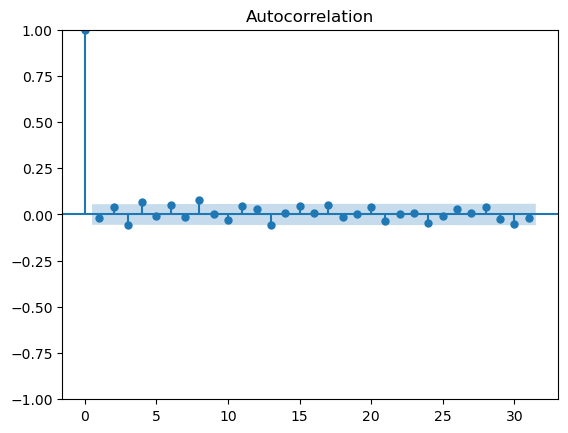

In [50]:
acf = plot_acf(df1["first_diff_Close"].dropna())
# q = 1 ---> assume by lookig at picture

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


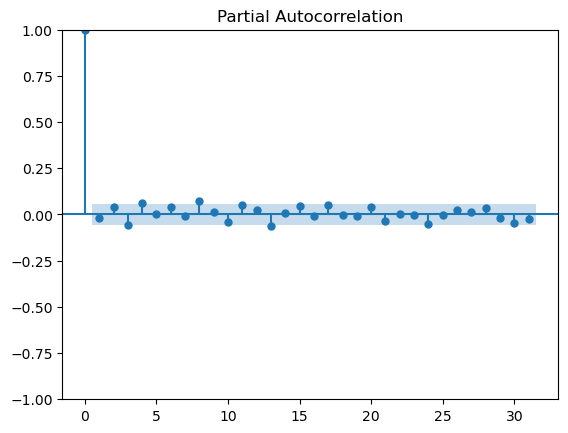

In [51]:
acf12 = plot_pacf(df1["first_diff_Close"].dropna())
# p = 1
# d = seasonal different , here d =1

In [52]:
df1.shape

(1234, 7)

In [53]:
### split train and test data
df1.head(3)

,High,Low,Open,Close,Volume,Adj Close,first_diff_Close
Date,,,,,,,
2017-11-15,417.549988,407.000000,414.299988,408.649994,9867270,408.649994,NaN
2017-11-16,415.899994,411.350006,411.350006,413.450012,6291441,413.450012,4.800018
2017-11-17,423.450012,417.000000,419.450012,421.799988,6191428,421.799988,8.349976


In [54]:
df1.tail(3)

,High,Low,Open,Close,Volume,Adj Close,first_diff_Close
Date,,,,,,,
2022-11-10,420.549988,409.200012,420.5,412.200012,26251660,412.200012,-20.949982
2022-11-11,425.500000,414.700012,420.0,423.500000,19296401,423.500000,11.299988
2022-11-14,437.700012,423.500000,424.0,433.700012,17988155,433.700012,10.200012


<AxesSubplot:xlabel='Date'>

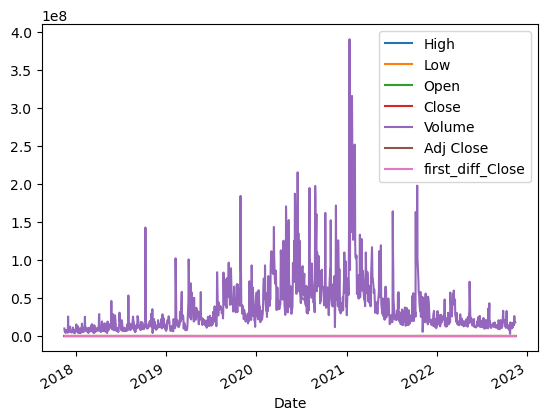

In [55]:
df1.plot()

In [56]:
from datetime import datetime,timedelta
train_dataset_end=datetime(2021,12,1)
test_dataset_end=datetime(2022,11,11)


In [57]:
train_data=df1[:train_dataset_end]
test_data=df1[train_dataset_end+timedelta(days=1):test_dataset_end]

In [58]:
train_data

,High,Low,Open,Close,Volume,Adj Close,first_diff_Close
Date,,,,,,,
2017-11-15,417.549988,407.000000,414.299988,408.649994,9867270,408.649994,NaN
2017-11-16,415.899994,411.350006,411.350006,413.450012,6291441,413.450012,4.800018
2017-11-17,423.450012,417.000000,419.450012,421.799988,6191428,421.799988,8.349976
2017-11-20,425.700012,420.100006,421.000000,423.000000,4051153,423.000000,1.200012
2017-11-21,430.000000,422.500000,424.450012,424.250000,6745407,424.250000,1.250000
...,...,...,...,...,...,...,...
2021-11-25,495.149994,486.500000,490.799988,492.750000,15336539,492.750000,4.100006
2021-11-26,486.750000,458.000000,486.000000,460.200012,51787989,460.200012,-32.549988
2021-11-29,470.750000,443.100006,457.000000,461.450012,42819150,461.450012,1.250000


<AxesSubplot:xlabel='Date'>

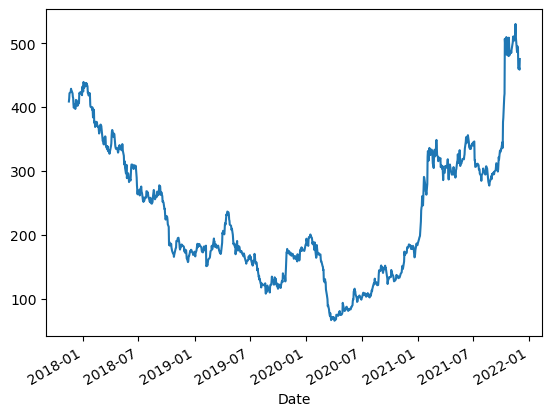

In [59]:
train_data['Close'].plot()

In [60]:
test_data

,High,Low,Open,Close,Volume,Adj Close,first_diff_Close
Date,,,,,,,
2021-12-02,480.450012,471.700012,479.399994,479.100006,21012008,479.100006,3.850006
2021-12-03,484.700012,477.299988,480.000000,480.100006,20948900,480.100006,1.000000
2021-12-06,480.899994,466.000000,480.100006,467.200012,17473075,467.200012,-12.899994
2021-12-07,484.899994,471.000000,476.850006,481.799988,21280797,481.799988,14.599976
2021-12-08,495.950012,483.500000,484.500000,493.899994,20581817,493.899994,12.100006
...,...,...,...,...,...,...,...
2022-11-04,426.000000,416.899994,418.200012,425.350006,12277023,425.350006,9.100006
2022-11-07,437.500000,428.250000,428.250000,435.000000,15058076,435.000000,9.649994
2022-11-09,441.200012,432.000000,439.200012,433.149994,14471443,433.149994,-1.850006


In [61]:
## create a ARIMA model
from statsmodels.tsa.arima.model import ARIMA

In [62]:
model_ARIMA=ARIMA(df1['Close'],order=(1,1,1))

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [63]:
model_Arima_fit=model_ARIMA.fit()

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [64]:
model_Arima_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                 1234
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -4306.345
Date:                Mon, 14 Nov 2022   AIC                           8618.690
Time:                        18:50:39   BIC                           8634.041
Sample:                             0   HQIC                          8624.465
                               - 1234                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8767      0.070    -12.481      0.000      -1.014      -0.739
ma.L1          0.8361      0.083     10.123      0.000       0.674       0.998
sigma2        63.2599      1.006     62.856      0.000      61.287      65.232
===================================================================================
Ljung-Box (L1) (Q):                   1.06   Jarque-Bera (JB):              9979.19
Prob(Q):                              0.30   Prob(JB):                         0.00
Heteroskedasticity (H):               3.21   Skew:                             0.95
Prob(H) (two-sided):                  0.00   Kurtosis:                        16.81
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [65]:
test_data

,High,Low,Open,Close,Volume,Adj Close,first_diff_Close
Date,,,,,,,
2021-12-02,480.450012,471.700012,479.399994,479.100006,21012008,479.100006,3.850006
2021-12-03,484.700012,477.299988,480.000000,480.100006,20948900,480.100006,1.000000
2021-12-06,480.899994,466.000000,480.100006,467.200012,17473075,467.200012,-12.899994
2021-12-07,484.899994,471.000000,476.850006,481.799988,21280797,481.799988,14.599976
2021-12-08,495.950012,483.500000,484.500000,493.899994,20581817,493.899994,12.100006
...,...,...,...,...,...,...,...
2022-11-04,426.000000,416.899994,418.200012,425.350006,12277023,425.350006,9.100006
2022-11-07,437.500000,428.250000,428.250000,435.000000,15058076,435.000000,9.649994
2022-11-09,441.200012,432.000000,439.200012,433.149994,14471443,433.149994,-1.850006


In [66]:
##prediction
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]
print(pred_start_date)
print(pred_end_date)

2021-12-02 00:00:00
2022-11-11 00:00:00


In [67]:
pred=model_Arima_fit.predict(start=pred_start_date,end=pred_end_date)
residuals=test_data['Close']-pred

In [68]:
pred

Date
2021-12-02    473.189954
2021-12-03    480.665963
2021-12-06    478.750094
2021-12-07    468.852798
2021-12-08    479.824902
                 ...    
2022-11-04    416.385882
2022-11-07    424.866656
2022-11-09    435.012038
2022-11-10    433.215096
2022-11-11    412.996794
Name: predicted_mean, Length: 235, dtype: float64

In [69]:
residuals

Date
2021-12-02     5.910052
2021-12-03    -0.565957
2021-12-06   -11.550082
2021-12-07    12.947190
2021-12-08    14.075092
                ...    
2022-11-04     8.964124
2022-11-07    10.133344
2022-11-09    -1.862044
2022-11-10   -21.015084
2022-11-11    10.503206
Length: 235, dtype: float64

<AxesSubplot:ylabel='Density'>

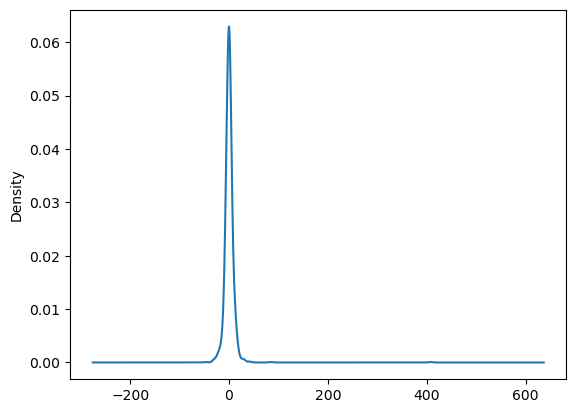

In [70]:
model_Arima_fit.resid.plot(kind='kde')

In [71]:
test_data['Predicted_ARIMA']=pred

C:\Users\BIPLAB\AppData\Local\Temp\ipykernel_11144\95659616.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['Predicted_ARIMA']=pred


<AxesSubplot:xlabel='Date'>

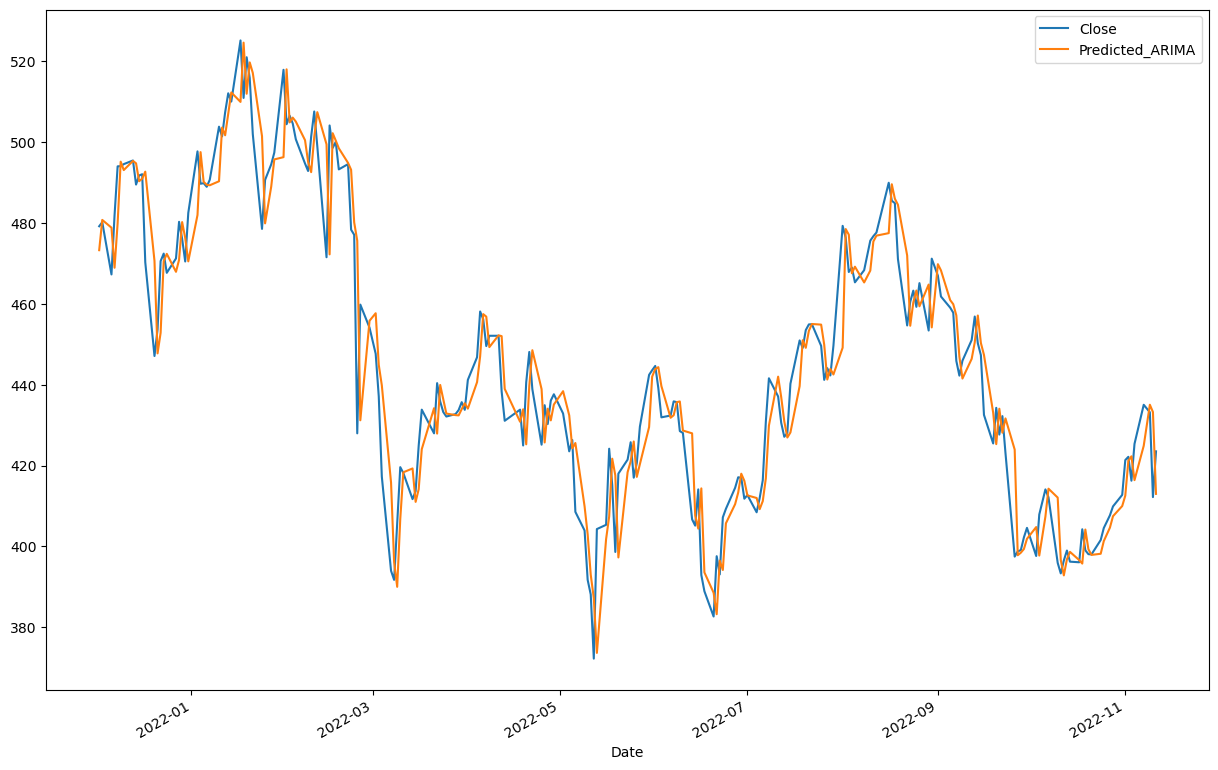

In [72]:
test_data[['Close','Predicted_ARIMA']].plot(figsize=(15,10))

In [73]:
pred

Date
2021-12-02    473.189954
2021-12-03    480.665963
2021-12-06    478.750094
2021-12-07    468.852798
2021-12-08    479.824902
                 ...    
2022-11-04    416.385882
2022-11-07    424.866656
2022-11-09    435.012038
2022-11-10    433.215096
2022-11-11    412.996794
Name: predicted_mean, Length: 235, dtype: float64

In [74]:
from sklearn.metrics import mean_squared_error
from math import sqrt

In [75]:
rmse= sqrt(mean_squared_error(pred,test_data['Close']))
rmse

10.28202412256133

In [76]:
test_data['Close'].mean()
# as rmse is very very lesser than mean then we can say our model is a good model

445.360851141747

In [77]:
##prediction
pred_start_date=test_data.index[-1]
pred_end_date='2022-12-31 00:00:00'
print(pred_start_date)
print(pred_end_date)

2022-11-11 00:00:00
2022-12-31 00:00:00


In [78]:
index_future_dates = pd.date_range(start='2022-11-11',end='2022-11-21')
pred1=model_Arima_fit.predict(start=len(df1),end=len(df1)+10)
pred1.index=index_future_dates
# residuals1=test_data['Close']-pred1

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [79]:
pred1

2022-11-11    434.226438
2022-11-12    433.764909
2022-11-13    434.169541
2022-11-14    433.814792
2022-11-15    434.125808
2022-11-16    433.853134
2022-11-17    434.092193
2022-11-18    433.882604
2022-11-19    434.066356
2022-11-20    433.905257
2022-11-21    434.046496
Freq: D, Name: predicted_mean, dtype: float64

<AxesSubplot:>

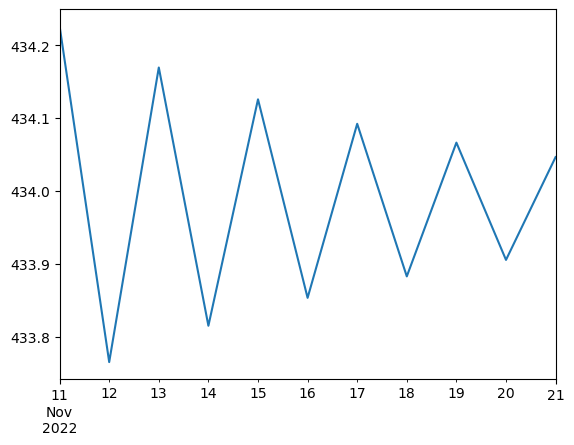

In [80]:
pred1.plot()

# USING MACHINE LEARNING

In [81]:
X = df1[["Open", "High", "Low", "Adj Close"]]
Y = df1["Close"]
X = X.to_numpy()
Y = Y.to_numpy()
Y = Y.reshape(-1, 1)

In [82]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=1)

In [83]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
X_train=ss.fit_transform(X_train)
X_test=ss.transform(X_test)

In [84]:
def create_model(model):
    model.fit(X_train,Y_train)
    Y_pred=model.predict(X_test)
#find the mean squared error
    print("Root Mean Squared error : ",sqrt(mean_squared_error(Y_test,Y_pred)))
#find the r2_score
    print("R2 Score : ",r2_score(Y_test,Y_pred))
    print("Training score : ",model.score(X_train,Y_train))
    print("Testing score : ",model.score(X_test,Y_test))
    return model,Y_pred

In [85]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
#create object of LinearRegression class
lr=LinearRegression()

In [86]:
lr,Y_pred=create_model(lr)

Root Mean Squared error :  2.188641252411443e-14
R2 Score :  1.0
Training score :  1.0
Testing score :  1.0


In [87]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt,Y_pred=create_model(dt)

Root Mean Squared error :  0.9962125393337716
R2 Score :  0.9999356673060025
Training score :  1.0
Testing score :  0.9999356673060025


In [88]:
from sklearn.svm import SVR
svr = SVR()
svr,Y_pred=create_model(svr)

Root Mean Squared error :  25.44754201522245
R2 Score :  0.9580222254577938


C:\Users\BIPLAB\anaconda3\lib\site-packages\sklearn\utils\validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Training score :  0.9612033412742224
Testing score :  0.9580222254577938


In [89]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(max_depth=3)
rfr,Y_pred=create_model(rfr)

Root Mean Squared error :  12.63750298453798
R2 Score :  0.989647380009244
Training score :  0.9901122614007462
Testing score :  0.989647380009244


C:\Users\BIPLAB\AppData\Local\Temp\ipykernel_11144\3388468506.py:2: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(X_train,Y_train)


In [90]:
a=pd.DataFrame(Y_pred)
a

,0
0,487.970418
1,176.276606
2,301.771572
3,301.771572
4,130.699934
...,...
366,421.377709
367,130.699934
368,176.276606
369,421.377709


<AxesSubplot:>

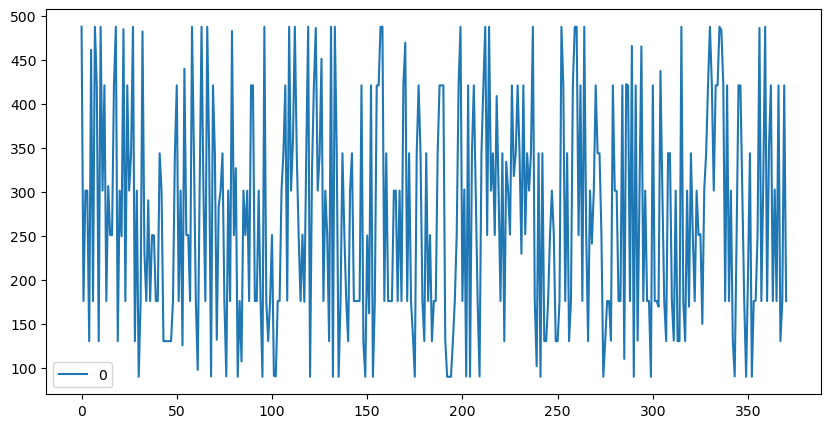

In [91]:
a.plot(figsize=(10,5))